# Exposure Time Calculations for Constraining the presence of polarized speckles at the HLC Band-1 Focal Plane

In [275]:
# Package inputs
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import proper
import roman_preflight_proper
from corgisim import scene, instrument
from tqdm import tqdm
from pathlib import Path
from astropy.io import fits

In [276]:
# USER INPUTS
star_choice = "Beta Car" # must be in 'starlist'
cr_rate = 0 # Keeping zero for purposes of this simulation
contrast = 2e-7
use_probe = 0 # 0, 1

assert contrast in [1e-5, 2e-7, 3e-8, 5e-9, 2e-9]
assert use_probe in [0, 1]

# Load and scale the probes according to contrast

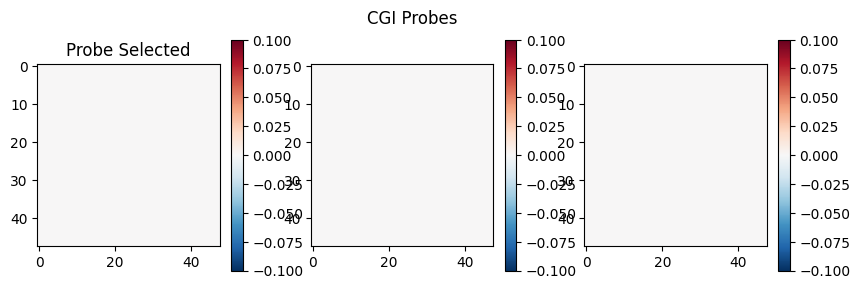

In [277]:
# Load the probe offices
PROBE_SELECT = 0
probepath = Path.home() / 'corgihowfsc/corgihowfsc/model/probes'
probe0file = probepath / 'nfov_dm_dmrel_4_1.0e-05_cos.fits'
probe1file = probepath / 'nfov_dm_dmrel_4_1.0e-05_sinlr.fits'
probe2file = probepath / 'nfov_dm_dmrel_4_1.0e-05_sinud.fits'

# Get the scaling from cgi-howfsc
scaling = {
    1e-5: 1.,
    2e-7: 1 / np.sqrt(10),
    3e-8: 1 / 10,
    5e-9: 1 / 10,
    2e-9: 1 / 10
}

# Grab and apply scale from dictionary
scale = scaling[contrast] * use_probe
probe0 = fits.getdata(probe0file) * scale
probe1 = fits.getdata(probe1file) * scale
probe2 = fits.getdata(probe2file) * scale
probes = [probe0, probe1, probe2]
probe = probes[PROBE_SELECT]

plt.figure(figsize=[10, 3])
plt.suptitle("CGI Probes")
for i, probe in enumerate([probe0, probe1, probe2]):
    plt.subplot(1, 3, i+1)
    if i == PROBE_SELECT:
        plt.title("Probe Selected")
    plt.imshow(probe, cmap="RdBu_r")
    plt.colorbar()
plt.show()

# Load the deformable mirror

In [278]:
rootname = Path.home() / f'roman_pol_etc/dm_settings/'

# init dms based on selected contrast
dm1 = proper.prop_fits_read(rootname / f"hlc_ni_{contrast}_dm1_v.fits")
dm2 = proper.prop_fits_read(rootname / f"hlc_ni_{contrast}_dm2_v.fits")

# Set up reference star

In [279]:
# Star dictionaries
starlist = ["Beta Car", "Beta Lib", "Beta TrA", "Gamma Peg"]
bet_car = {"name": r"$\Beta$"+" Carinae", "Vmag": 1.69, "Spectal Type":"A1III"}
bet_lib = {"name": r"$\Beta$"+" Librae", "Vmag": 2.62, "Spectal Type":"B8V"}
bet_tra = {"name": r"$\Beta$"+" Triangulae Australis", "Vmag": 2.85, "Spectal Type":"F1V"}
gam_peg = {"name": r"$\gamma$"+" Pegisae", "Vmag": 2.84, "Spectal Type":"B2IV"}

match star_choice:
    case "Beta Car":
        star_params = bet_car
    case "Beta Lib":
        star_params = bet_lib
    case "Beta TrA":
        star_params = bet_tra
    case "Gamma Peg":
        star_params = gam_peg
    case _:
        raise ValueError(f"star choice '{star_choice}' not in {starlist}")

## Generate the Polarized Scenes for both the 'POL0' and 'POL45' prisms

In [280]:
# Ensure we have the Proper model
roman_preflight_proper.copy_here()

# USER INPUTS
Vmag = star_params["Vmag"]
spectral_type = star_params["Spectal Type"]
cgi_mode = 'excam'
bandpass_corgisim = '1B'
cor_type = 'hlc'
pixscale_mas = 21.8 # mas/pix
output_dim = 51

# Set up a mask at the IWA
pixscale_rad = pixscale_mas / 1e3 / 206265
pixscale_lamD = 2.4 / 575e-9 * pixscale_rad
array_center = output_dim // 2
mask = np.zeros([output_dim, output_dim])
mask_fulldh = np.copy(mask)
rad = pixscale_lamD * output_dim / 2
x = np.linspace(-rad, rad, output_dim)
x, y = np.meshgrid(x, x)
r = np.hypot(y, x)
mask[r <= 5] = 1
mask[r <= 3] = 0

# Init scene
host_star_properties = {
    'Vmag': Vmag,
    'spectral_type': spectral_type,
    'magtype': 'vegamag'
}
base_scene = scene.Scene(host_star_properties, point_source_info=None)

# Init instrument
optics_keywords = {
        'cor_type':cor_type,
        'use_errors':2,
        'polaxis':10,
        'output_dim':output_dim,
        'prism':'POL0',
        'use_dm1':1,
        'dm1_v':dm1 + probe,
        'use_dm2':1,
        'dm2_v':dm2,
        'use_fpm':1,
        'use_lyot_stop':1,
        'use_field_stop':1
}

# Remember to clear polarized scenes
polarized_scenes = []
for prism in ['POL0', 'POL45']:

    # Swap the wollaston prism
    optics_keywords['prism'] = prism
    print(f"Simulating PSF with prism  = {optics_keywords['prism']}") 
    
    # re-init optics and generate the PSF
    optics = instrument.CorgiOptics(cgi_mode, bandpass_corgisim, optics_keywords=optics_keywords, if_quiet=True)
    sim_scene = optics.get_host_star_psf(base_scene)
    polarized_scenes.append(sim_scene)

sim_scene_Q = polarized_scenes[0]
sim_scene_U = polarized_scenes[1]

Simulating PSF with prism  = POL0
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL45
CorgiOptics initialized with proper keywords.


# Analoge Detector Simulations

## Explore Gain settings given number of frames and coadds

Running Experment for Different Gains:   0%|                                      | 0/11 [00:00<?, ?it/s]/home/jarenashcraft/corgisim/corgisim/instrument.py:1187: UserWarning: Detector noise will be different for each sub frame in polarimetry mode. For accurate detector image with noise, please generate full frame image.
  warnings.warn('Detector noise will be different for each sub frame in polarimetry mode. For accurate detector image with noise, please generate full frame image.')
/tmp/ipykernel_144061/1972428479.py:76: RuntimeWarning: divide by zero encountered in divide
  var_q = q_img**2 * (var_q / (Q_img**2) + var_i / (I_img**2))
/tmp/ipykernel_144061/1972428479.py:76: RuntimeWarning: invalid value encountered in multiply
  var_q = q_img**2 * (var_q / (Q_img**2) + var_i / (I_img**2))
/tmp/ipykernel_144061/1972428479.py:84: RuntimeWarning: divide by zero encountered in divide
  var_u = u_img**2 * (var_u / (U_img**2) + var_i / (I_img**2))
/tmp/ipykernel_144061/1972428479.py:84: Ru

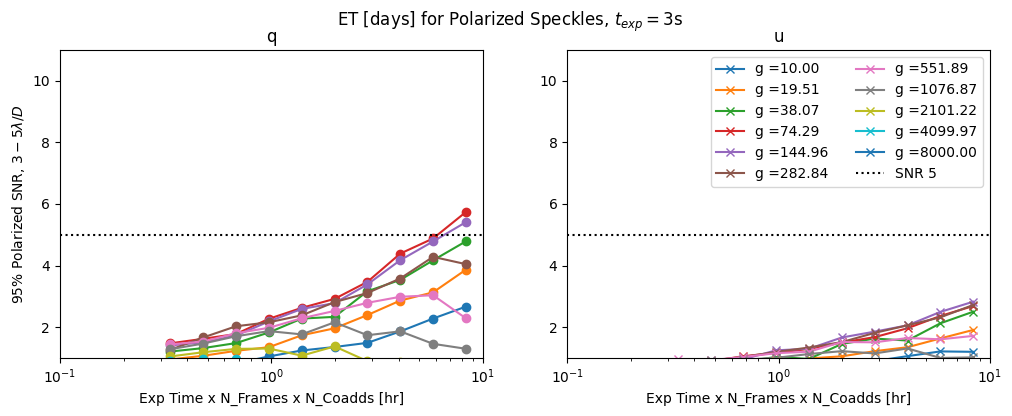

In [281]:
gains = np.logspace(1, np.log10(8000), 11)
N_FRAMES = 10
s_to_hr = 1 / 3600
n_coadds = np.logspace(np.log10(20),
                       np.log10(500),
                       10) / 1
single_texp = 3

# mostly for debugging
plot_intermediates = False

fig, ax = plt.subplots(ncols=2, figsize=[12, 4])
fig.suptitle("ET [days] for Polarized Speckles, "+r"$t_{exp}=$"+f"{single_texp}s")
for gain in tqdm(gains, desc="Running Experment for Different Gains"):

    mean_Qs = []
    mean_Us = []
    mean_DoLPs = []

    
    # Re-initialize detector
    emccd_keywords ={'em_gain':gain,
                     'cr_rate':cr_rate}
    detector = instrument.CorgiDetector(emccd_keywords,
                                        photon_counting=False)
    
    for i, n_coadd in enumerate(n_coadds):

        N_COADDS = int(n_coadd)
        
        I0s = []
        I90s = []
        I45s = []
        I135s = []
        
        for j in range(N_FRAMES):
            I0 = 0
            I90 = 0
            I45 = 0
            I135 = 0
    
            for _ in range(N_COADDS):
                
                # Re-sample scene from flux map
                sim_scene = detector.generate_detector_image(sim_scene_Q, single_texp)
                I0 += sim_scene.image_on_detector.data[0]
                I90 += sim_scene.image_on_detector.data[1]
                
                # Re-sample scene from flux map
                sim_scene = detector.generate_detector_image(sim_scene_U, single_texp)
                I45 += sim_scene.image_on_detector.data[0]
                I135 += sim_scene.image_on_detector.data[1]

            I0s.append(I0)
            I90s.append(I90)
            I45s.append(I45)
            I135s.append(I135)

        # Get mean and variance
        I0 = np.nanmean(I0s, axis=0)
        I90 = np.nanmean(I90s, axis=0)
        I45 = np.nanmean(I45s, axis=0)
        I135 = np.nanmean(I135s, axis=0)

        var_I0 = np.nanvar(I0s, axis=0)
        var_I90 = np.nanvar(I90s, axis=0)
        var_I45 = np.nanvar(I45s, axis=0)
        var_I135 = np.nanvar(I135s, axis=0)
    
        # Uncertainty Propagation - Q
        Q_img = I0 - I90
        I_img = I0 + I90
        q_img = Q_img / I_img
        var_q = var_I0 + var_I90
        var_i = var_I0 + var_I90
        var_q = q_img**2 * (var_q / (Q_img**2) + var_i / (I_img**2))
        
        # Uncertainty Propagation - U
        U_img = I45 - I135
        I_img = I45 + I135
        u_img = U_img / I_img
        var_u = var_I45 + var_I135
        var_i = var_I45 + var_I135
        var_u = u_img**2 * (var_u / (U_img**2) + var_i / (I_img**2))
        
        q_snr = np.abs(q_img / np.sqrt(var_q))
        u_snr = np.abs(u_img / np.sqrt(var_u))
        
        # Find max signal in near-IWA annulus
        mean_Q = np.nanpercentile(q_snr[mask==1], 90)
        mean_U = np.nanpercentile(u_snr[mask==1], 90)
        mean_Qs.append(mean_Q)
        mean_Us.append(mean_U)

    # Begin plotting standard deviation of polarized intensity in annulus
    # Multiply by 2 to account for separate Q and U exposures
    ax[0].plot(N_FRAMES * s_to_hr * 2 * single_texp * n_coadds, mean_Qs, marker="o", label=f"g ={gain:.2f}")
    ax[1].plot(N_FRAMES * s_to_hr * 2 * single_texp * n_coadds, mean_Us, marker="x", label=f"g ={gain:.2f}")

# Params for Q
ax[0].set_title("q")
ax[0].set_xscale("log")
ax[0].set_xlabel("Exp Time x N_Frames x N_Coadds [hr]")
ax[0].set_ylabel(r"$95\%$"+" Polarized SNR, "+r"$3-5\lambda/D$")
ax[0].set_ylim(1, 11)
ax[0].set_xlim(1e-1, 10)
ax[0].hlines(5, 1e-1, 10, label="SNR 5", linestyle="dotted", color="k")

ax[1].set_title("u")
ax[1].set_xscale("log")
ax[1].set_xlabel("Exp Time x N_Frames x N_Coadds [hr]")
ax[1].set_ylim(1, 11)
ax[1].hlines(5, 1e-1, 10, label="SNR 5", linestyle="dotted", color="k")
ax[1].set_xlim(1e-1, 10)
plt.legend(ncols=2)
plt.show()

In [283]:
n_coadds[7]

np.float64(244.52128480976896)

In [298]:
gain = 121
N_COADDS = int(n_coadds[7])
single_texp = 3
N_FRAMES = 10

# mostly for debugging

emccd_keywords ={'em_gain':gain,
                 'cr_rate':cr_rate}
detector = instrument.CorgiDetector(emccd_keywords,
                                    photon_counting=False)

N_FRAMES = int(N_FRAMES)

I0s = []
I90s = []
I45s = []
I135s = []

for x in range(N_FRAMES):
    
    I0 = 0.
    I90 = 0.
    I45 = 0.
    I135 = 0.

    for _ in range(N_COADDS):
        
        # Re-sample scene from flux map
        sim_scene = detector.generate_detector_image(sim_scene_Q, single_texp)
        I0 += sim_scene.image_on_detector.data[0].astype(float)
        I90 += sim_scene.image_on_detector.data[1].astype(float)
        
        # Re-sample scene from flux map
        sim_scene = detector.generate_detector_image(sim_scene_U, single_texp)
        I45 += sim_scene.image_on_detector.data[0].astype(float)
        I135 += sim_scene.image_on_detector.data[1].astype(float)
    
    I0s.append(I0)
    I90s.append(I90)
    I45s.append(I45)
    I135s.append(I135)

# Get mean and variance
I0 = np.nanmean(I0s, axis=0)
I90 = np.nanmean(I90s, axis=0)
I45 = np.nanmean(I45s, axis=0)
I135 = np.nanmean(I135s, axis=0)

var_I0 = np.nanvar(I0s, axis=0)
var_I90 = np.nanvar(I90s, axis=0)
var_I45 = np.nanvar(I45s, axis=0)
var_I135 = np.nanvar(I135s, axis=0)

# Uncertainty Propagation - Q
Q_img = I0 - I90
q_img = Q_img #/ I_img
var_q = var_I0 + var_I90
var_i = var_I0 + var_I90
#var_q = q_img**2 * (var_q / (Q_img**2) + var_i / (I_img**2))

# Uncertainty Propagation - U
U_img = I45 - I135
I_img = I45 + I135
u_img = U_img #/ I_img
var_u = var_I45 + var_I135
var_i = var_I45 + var_I135
#var_u = u_img**2 * (var_u / (U_img**2) + var_i / (I_img**2))

q_snr = np.abs(q_img / np.sqrt(var_q))
u_snr = np.abs(u_img / np.sqrt(var_u))

# Find max signal in near-IWA annulus
mean_Q = np.nanpercentile(q_snr[mask==1], 90)
mean_U = np.nanpercentile(u_snr[mask==1], 90)

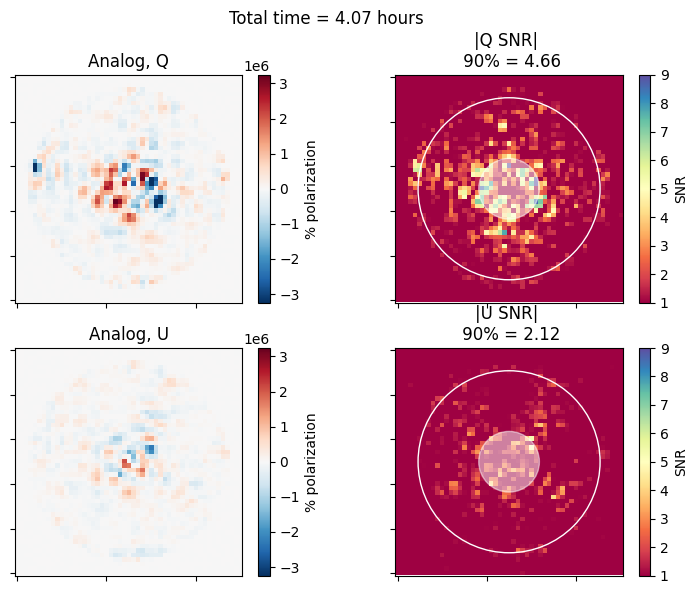

In [299]:
from matplotlib.colors import LogNorm
clim = np.max([q_img, u_img]) * 100

plt.figure(figsize=[9, 6.5])
plt.suptitle(f"Total time = {(2 * N_COADDS * N_FRAMES * single_texp) * s_to_hr:.2f} hours")
plt.subplot(221)
plt.title("Analog, Q")
plt.imshow(q_img * 100, cmap="RdBu_r", vmin=-clim, vmax=clim)
plt.colorbar(label="% polarization")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.subplot(222)
plt.title(f"|Q SNR| \n 90% = {mean_Q:.2f}")
plt.imshow(q_snr, cmap="Spectral", vmin=1, vmax=9)
plt.colorbar(label="SNR")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")
ax = plt.gca()
ax.add_patch(IWA)
ax.add_patch(OWA)

plt.subplot(223)
plt.title("Analog, U")
plt.imshow(u_img * 100, cmap="RdBu_r", vmin=-clim, vmax=clim)
plt.colorbar(label="% polarization")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.subplot(224)
plt.title(f"|U SNR| \n 90% = {mean_U:.2f}")
plt.imshow(u_snr, cmap="Spectral", vmin=1, vmax=9)
plt.colorbar(label="SNR")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")
ax = plt.gca()
ax.add_patch(IWA)
ax.add_patch(OWA)
plt.show()

## Checking that the first-order error propagation works

According to Brian Kern, we want $\sigma_{Q}, \sigma_{U} << max(Q,U)$ to use the first-order error propagation for sums in quadrature

/tmp/ipykernel_144061/2202904862.py:10: RuntimeWarning: divide by zero encountered in divide
  plt.imshow(np.sqrt(var_q) / max_val / mask_fulldh, cmap="plasma", norm=LogNorm())
/tmp/ipykernel_144061/2202904862.py:15: RuntimeWarning: divide by zero encountered in divide
  plt.imshow(np.sqrt(var_u) / max_val / mask_fulldh, cmap="plasma", norm=LogNorm())


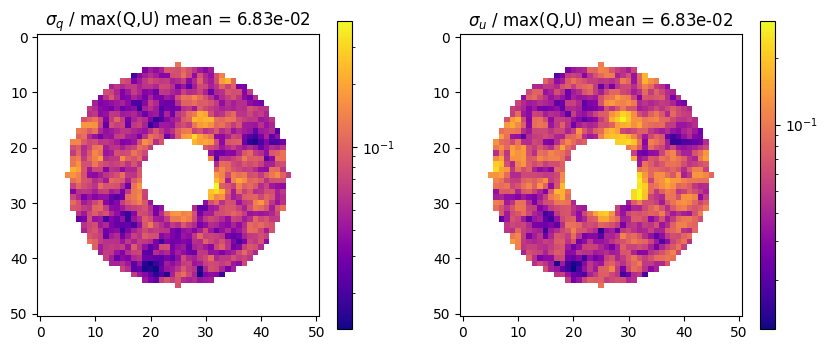

In [300]:
mask_fulldh = np.zeros_like(mask)
mask_fulldh[r <= 9] = 1
mask_fulldh[r <= 3] = 0

max_val = np.max([Q_img[mask_fulldh==1], U_img[mask_fulldh==1]])
plt.figure(figsize=[10 ,4])
plt.subplot(121)
mean = np.mean((np.sqrt(var_q) / max_val)[mask_fulldh==1])
plt.title(r"$\sigma_q$ / max(Q,U) "+f"mean = {mean:.2e}")
plt.imshow(np.sqrt(var_q) / max_val / mask_fulldh, cmap="plasma", norm=LogNorm())
plt.colorbar()
plt.subplot(122)
mean = np.mean((np.sqrt(var_q) / max_val)[mask_fulldh==1])
plt.title(r"$\sigma_u$ / max(Q,U) "+f"mean = {mean:.2e}")
plt.imshow(np.sqrt(var_u) / max_val / mask_fulldh, cmap="plasma", norm=LogNorm())
plt.colorbar()

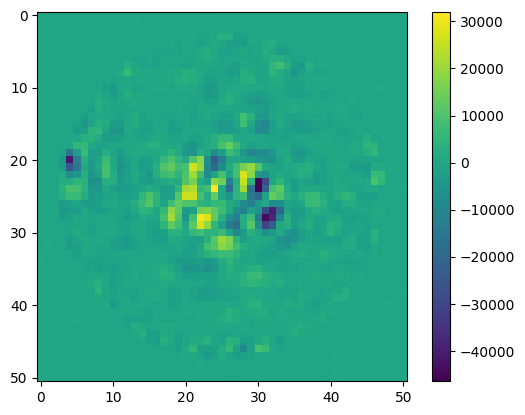

In [290]:
plt.imshow(Q_img)
plt.colorbar()